<a href="https://colab.research.google.com/github/100522128/g81_P2_03_Aprendizaje_Automatico/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 2 - Determinacion Grupos de Estrellas
**Miembros del grupo:**

Christian Cano -> 100522320

Adrián Curell -> 100522128

[Repositorio de github](https://github.com/100522128/g81_P2_03_Aprendizaje_Automatico.git)

##1 Visualización de los datos

###1.1 Carga del dataset

Cargamos el archivo “starts_data.csv" usando pandas

In [38]:
import pandas as pd
from google.colab import files
archivos = files.upload()
df=pd.read_csv("stars_data.csv")

Saving stars_data.csv to stars_data (2).csv


###1.2 Tipos de variables

Ahora clasificamos las variables segun su tipo

In [39]:
print(df.dtypes.values)

[dtype('int64') dtype('float64') dtype('float64') dtype('float64')
 dtype('O') dtype('O')]


Como podemos ver todas son o int64/float64 o Object por lo que podemos hacer un clasificador automático que las separe en numéricas (int64/float64) o no numéricas (Object), que se dividirá en categóricas o ordinales.

**En este caso todas serán ordinales.*

Para realizarlo haremos:

1. Dividir las variables en numéricas o no numéricas según su dtype utilizando la función select_dtypes.

2. De las no numéricas sacamos con unique los distintos valores que tienen y con nunique el numero total.

3. Creamos una lista para el tipo (numéricas o ordinales).

4. Recorrer el dataframe con un bucle y rellenando estas listas con los datos de las variables.

5. Crear un dataframe donde introduzcamos los datos de estas listas juntos al nombre y dtype de cada variable.

In [40]:
import numpy as np

# Clasificación automática de variables
variables_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
variables_no_numericas = df.select_dtypes(include=['object']).columns.tolist()

N_unique = []
Valores = []

for i in variables_no_numericas:
  N_unique.append(df[i].nunique())
  Valores.append(df[i].unique())

cardinalidad = pd.DataFrame({
    'Variable': variables_no_numericas,
    'N_unique': N_unique,
    'Valores': Valores
})
print(cardinalidad[['Variable', 'N_unique', 'Valores']].to_string(index=False))

variables_ordinales = []
variables_ordinales = variables_no_numericas.copy()

# Imprimimos la clasificación
print('\n=== Variables NUMÉRICAS ===')
print(variables_numericas)

print('\n=== Variables ORDINALES ===')
print(variables_ordinales)

# Creamos listas vacías donde almacenar los tipos y roles de cada variable
lista_tipo = []

# Recorrer columnas
for c in df.columns:
  # Tipo (Numérica o Ordinal)
  if c in variables_numericas:
    lista_tipo.append('Numérica')
  else:
    lista_tipo.append('Ordinal')


# Crear DataFrame final
resumen_tipos = pd.DataFrame({
    'Variable': df.columns,
    'Dtype': df.dtypes.values,
    'Tipo': lista_tipo,
})

print('\n', resumen_tipos.to_string(index=True))

      Variable  N_unique                                                                                                                                                                                       Valores
         Color        17 [Red, Blue White, White, Yellowish White, Blue white, Pale yellow orange, Blue, Blue-white, Whitish, yellow-white, Orange, White-Yellow, white, yellowish, Yellowish, Orange-Red, Blue-White]
Spectral_Class         7                                                                                                                                                                         [M, B, A, F, O, K, G]

=== Variables NUMÉRICAS ===
['Temperature', 'L', 'R', 'A_M']

=== Variables ORDINALES ===
['Color', 'Spectral_Class']

          Variable    Dtype      Tipo
0     Temperature    int64  Numérica
1               L  float64  Numérica
2               R  float64  Numérica
3             A_M  float64  Numérica
4           Color   object   Ordinal
5  Spectral_

Vemos que son variables ordinales Color y Spectral_Class, siendo el resto variables numericas

###1.3 Valores faltantes

Ahora comprobamos si hay valores faltantes en alguna variable

In [41]:
faltan = pd.DataFrame({
    'Variable': df.columns,
    'Valores faltantes': df.isnull().sum().values,
    '% faltantes': (df.isnull().mean() * 100).round(2).values
})
faltan = faltan[faltan['Valores faltantes'] > 0]

if faltan.empty:
    print('No hay valores faltantes (NaN) en el dataset.')
else:
    print('Variables con valores faltantes:')
    print(faltan.to_string(index=False))

No hay valores faltantes (NaN) en el dataset.


Tras la comprobacion se puede afirmar que no existen valores faltantes por lo que podemos pasar al tratamiento de las variables ordinales directamente

###1.4 Conversión de variables ordinales

En esta etapa del preprocesado, se procedió a la transformación de las variables cualitativas Color y Spectral_Class en magnitudes numéricas mediante un mapeo ordinal. Esta decisión técnica se fundamenta en que ambas variables poseen una jerarquía física intrínseca vinculada a la termodinámica estelar.


Variable Color: Se estableció una escala numérica donde el valor mínimo ($0$) se asignó a las longitudes de onda asociadas a menores temperaturas (colores cálidos como el rojo) y el valor máximo a las estrellas de mayor temperatura superficial (colores de alta energía como el azul).

Variable Spectral_Class: Se aplicó una lógica análoga siguiendo estrictamente la secuencia térmica proporcionada en las directrices de la práctica: (O, B, A, F, G, K, M). En este modelo, las estrellas de tipo M (más frías) representan el extremo inferior de la escala, mientras que las de tipo O (más calientes) definen el extremo superior, preservando así la relación de energía necesaria para el análisis de clustering posterior.

Esta codificación permite que los algoritmos de aprendizaje no supervisado interpreten correctamente la proximidad física entre los diferentes tipos de estrellas, factor que se perdería con otras técnicas como el one-hot encoding.

In [42]:
# 1. Configuración inicial
SEMILLA = 100522320
np.random.seed(SEMILLA)

def transformar_ordinales(X_in):
    X_df = X_in.copy()

    # Diccionarios de mapeo basados en criterios térmicos
    spectral_map = {'o': 6, 'b': 5, 'a': 4, 'f': 3, 'g': 2, 'k': 1, 'm': 0}
    color_map = {
        'red': 0, 'orange red': 1, 'orange': 2, 'pale yellow orange': 3,
        'yellowish': 4, 'yellowish white': 5, 'yellow white': 5,
        'white yellow': 5, 'whitish': 6, 'white': 7, 'blue white': 8, 'blue': 9
    }

    # Limpieza de texto y aplicación de mapeo
    X_df['Spectral_Class'] = X_df['Spectral_Class'].str.lower().map(spectral_map)
    X_df['Color'] = X_df['Color'].str.lower().str.replace('-', ' ').str.strip().map(color_map)

    return X_df

## 2 PCA

Para que sea más sencillo visualizar los datos vamos a usar PCA con los 2 componentes principales. Lo primero será visualizar la varianza explicada acumulada, que como se puede observar, con solo 4 componentes se explica más del 96% de la varianza y con 2 podemos explicar hasta un 85%.

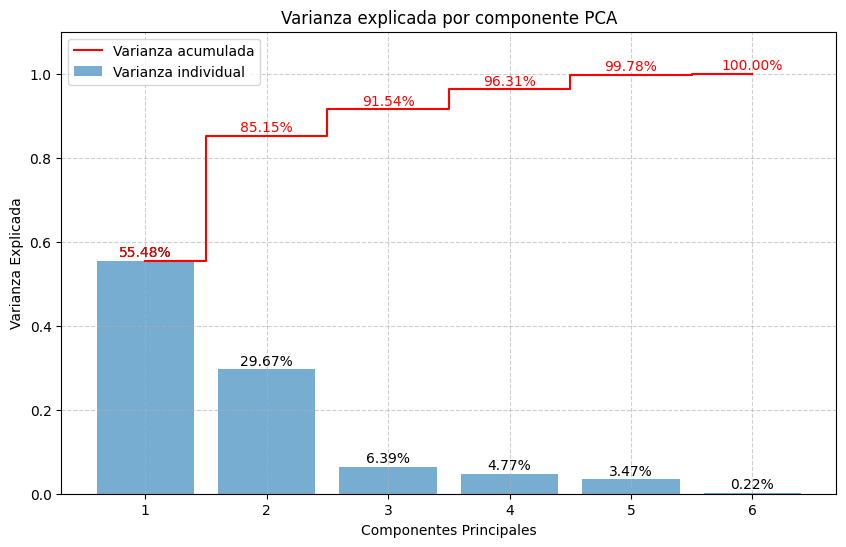

In [43]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer

# Definimos el paso de transformación de las ordinales usando FunctionTransformer
paso_ordinal = FunctionTransformer(transformar_ordinales)

# Creamos el Pipeline de PCA
pipeline_pca = Pipeline([
    ('limpieza_ordinal', paso_ordinal),
    ('escalador', StandardScaler()),
    ('pca', PCA())
])

# Ajustar y transformar
X_pca = pipeline_pca.fit_transform(df)
pca = pipeline_pca.named_steps['pca']

# Varianza explicada y acumulada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot de Varianza Explicada y Acumulada
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, label='Varianza individual')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Varianza acumulada', color='red')

# Añadir valores exactos
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    plt.text(i + 1, ev + 0.01, f"{ev:.2%}", ha='center')
    plt.text(i + 1, cv + 0.01, f"{cv:.2%}", ha='center', color='red')

plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Varianza explicada por componente PCA')
plt.legend(loc='best')
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Ahora, nos quedaremos con los 2 componentes más importantes, como explica el enunciado:

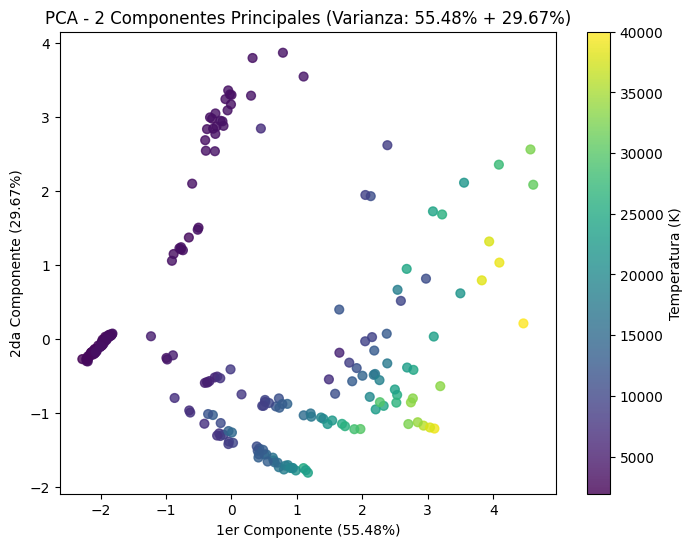

In [44]:
# Pipeline de PCA
pipeline_pca = Pipeline([
    ('limpieza_ordinal', paso_ordinal),
    ('escalador', StandardScaler()),
    ('pca', PCA(n_components=2))
])

# Ajustar y transformar
X_pca = pipeline_pca.fit_transform(df)
pca = pipeline_pca.named_steps['pca']

# Visualizar
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Temperature'], s=40, cmap='viridis', alpha=0.8)
plt.title('PCA - 2 Componentes Principales (Varianza: {:.2%} + {:.2%})'.format(explained_variance[0], explained_variance[1]))
plt.xlabel('1er Componente ({:.2%})'.format(explained_variance[0]))
plt.ylabel('2da Componente ({:.2%})'.format(explained_variance[1]))
plt.colorbar(label='Temperatura (K)')
plt.show()

## 3 K-Means

En esta sección aplicaremos el algoritmo K-Means sobre las 2 componentes principales obtenidas mediante PCA. Para determinar el número óptimo de clusters ($k$), evaluaremos un rango de posibles agrupaciones (de 2 a 10) utilizando dos métricas clave:

1. **Inercia (Método del Codo):** Mide la suma de las distancias al cuadrado de las muestras a su centroide más cercano. Buscamos el punto donde la curva forma un "codo", indicando que añadir más clusters no mejora significativamente la varianza explicada.
2. **Silhouette Score:** Mide cuán similar es un objeto a su propio cluster en comparación con otros clusters. Varía de -1 a 1, donde valores más altos indican agrupaciones mejor definidas.

Tras analizar estas métricas, elegiremos el $k$ óptimo, entrenaremos el modelo final y visualizaremos la distribución espacial de los clusters.

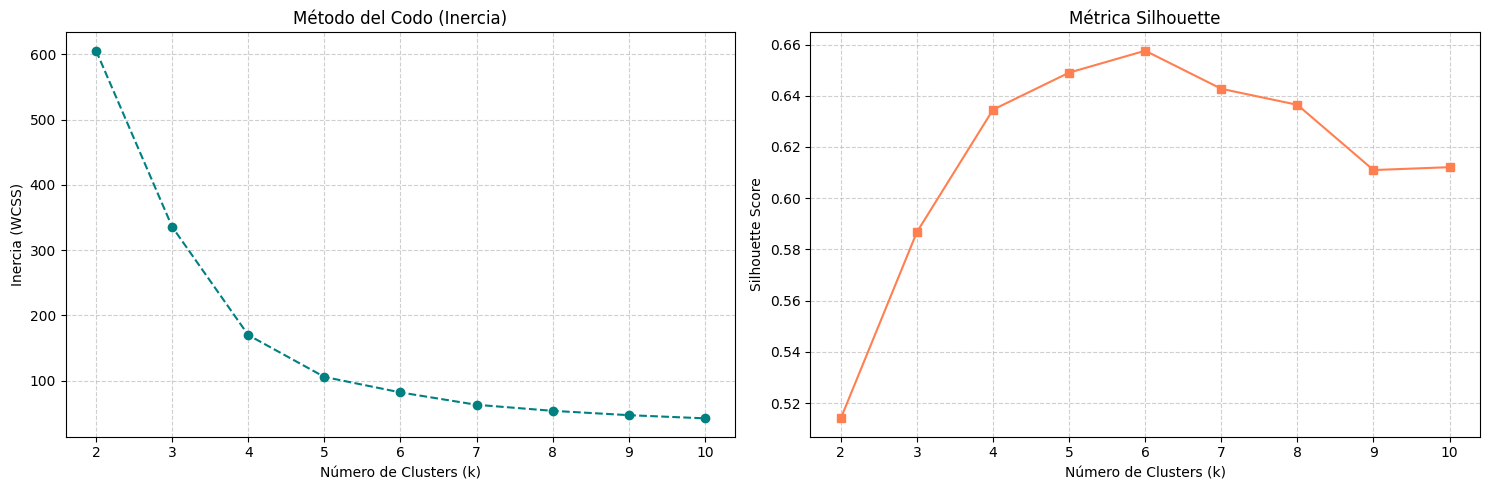

In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Definimos el rango de clusters a probar
rango_k = range(2, 11) # de 2 a 10 centroides
inercias = []
silhouette_scores = []

# Iteramos para calcular métricas por cada valor de k
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10)
    etiquetas = kmeans.fit_predict(X_pca)

    inercias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, etiquetas))

# Configuración de los gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Método del Codo
ax1.plot(rango_k, inercias, marker='o', linestyle='--', color='teal')
ax1.set_title('Método del Codo (Inercia)')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Silhouette Score
ax2.plot(rango_k, silhouette_scores, marker='s', linestyle='-', color='coral')
ax2.set_title('Métrica Silhouette')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 3.1 Decisión del hiperparámetro $k$ y Modelo Final

Al analizar las métricas generadas, podemos extraer conclusiones muy claras para elegir nuestro número óptimo de clusters:

1. **Método del Codo (Inercia):** Observamos que la suma de las distancias al cuadrado (WCSS) disminuye drásticamente hasta $k=4$, punto a partir del cual la curva comienza a aplanarse. Si bien el "codo" visual podría sugerir 4 o 5 clusters, la inercia en $k=6$ es baja y se encuentra en la zona de estabilización.
2. **Silhouette Score:** Esta métrica resulta determinante para nuestro caso. La gráfica muestra una tendencia ascendente que culmina en un **pico máximo muy evidente en $k=6$** (alcanzando un valor cercano a 0.66). Esto indica que al dividir los datos en 6 grupos obtenemos la máxima cohesión dentro de cada cluster y la mejor separación frente al resto.

**Conclusión:**
Las métricas respaldan la elección de **$k=6$**. Cabe destacar, que este valor coincide de forma exacta con la naturaleza física del problema, ya que la tabla de referencia del enunciado clasifica a estas estrellas en **6 tipos principales** (Enana roja, Enana marrón, Enana blanca, Estrella en secuencia principal, Super gigante e Hiper gigante).

Por tanto, procedemos a entrenar nuestro modelo final de K-Means fijando $k=6$.

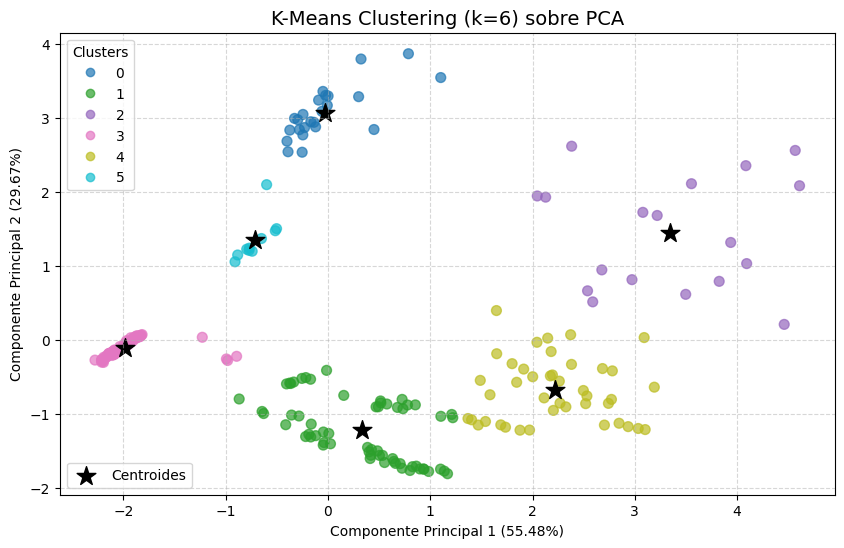

In [46]:
# Elegimos el hiperparámetro k óptimo
k_optimo = 6

# Entrenamos el modelo final
kmeans_final = KMeans(n_clusters=k_optimo, random_state=SEMILLA, n_init=10)
etiquetas_kmeans = kmeans_final.fit_predict(X_pca)

# Guardamos las etiquetas en el dataframe original para el análisis posterior
df['Cluster_KMeans'] = etiquetas_kmeans

# Visualización del clustering final
plt.figure(figsize=(10, 6))

# Dibujar los puntos coloreados por cluster
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=etiquetas_kmeans, cmap='tab10', s=50, alpha=0.7)

# Dibujar los centroides
centroides = kmeans_final.cluster_centers_
plt.scatter(centroides[:, 0], centroides[:, 1],
            c='black', marker='*', s=200, edgecolor='black', label='Centroides')

plt.title(f'K-Means Clustering (k={k_optimo}) sobre PCA', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({explained_variance[0]:.2%})')
plt.ylabel(f'Componente Principal 2 ({explained_variance[1]:.2%})')

# Crear leyenda para los clusters
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters", loc='upper left')
plt.gca().add_artist(legend1)
plt.legend(loc='lower left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4 Hierarchical Clustering

En esta sección aplicaremos el Clustering Jerárquico. A diferencia de K-Means, este algoritmo agrupa los datos pares a pares formando un árbol jerárquico.

Al igual que en la sección anterior, vamos a buscar con el índice Silhouette el mejor número de clusters para nuestros datos que como veremos después será 6 al igual que en k-means.

Para configurar correctamente el modelo, también evaluaremos distintas funciones de enlace (*linkage*), las cuales definen cómo se calcula la distancia entre los clusters recién formados:
* **Ward:** Minimiza la varianza dentro del cluster.
* **Complete (Maximum):** Considera la distancia máxima entre elementos de los clusters.
* **Average:** Considera la distancia media entre elementos de los clusters.
* **Single (Minimum):** Considera la distancia mínima entre elementos de los clusters.

Probaremos todas ellas, mediremos su *Silhouette Score* para evaluar la calidad geométrica de los grupos, y seleccionaremos automáticamente la mejor configuración para visualizar su **Dendrograma** y distribución final.

Evaluando combinaciones de 'k' y métodos de linkage:
--------------------------------------------------
--------------------------------------------------
 El MEJOR modelo es 'linkage=ward' con k=6
 Silhouette Score: 0.6440


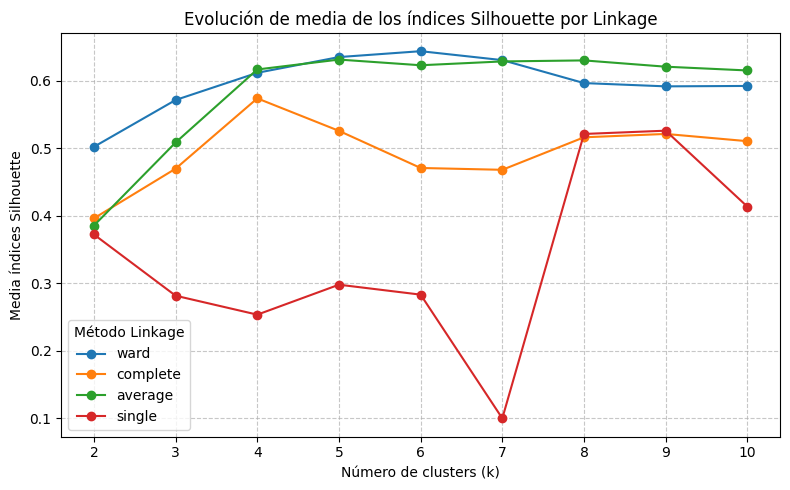

In [47]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

# Definimos los rangos a probar
range_n_clusters = range(2, 11)
metodos_linkage = ['ward', 'complete', 'average', 'single']

# Variables para guardar los resultados
resultados_hc = []
mejor_score = -1
mejor_linkage = ""
mejor_k = -1
mejores_etiquetas_hc = None

print("Evaluando combinaciones de 'k' y métodos de linkage:\n" + "-"*50)

# Bucle anidado: por cada 'k', probamos todos los 'linkage'
for k in range_n_clusters:
    for linkage in metodos_linkage:

        # Entrenamos el modelo
        hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage=linkage)
        etiquetas = hc.fit_predict(X_pca)

        # Calculamos la métrica
        score = silhouette_score(X_pca, etiquetas)

        # Guardamos el resultado de esta combinación
        resultados_hc.append({'k': k, 'Linkage': linkage, 'Silhouette Score': score})

        # Actualizamos el mejor modelo encontrado
        if score > mejor_score:
            mejor_score = score
            mejor_linkage = linkage
            mejor_k = k
            mejores_etiquetas_hc = etiquetas

print("-" * 50)
print(f" El MEJOR modelo es 'linkage={mejor_linkage}' con k={mejor_k}")
print(f" Silhouette Score: {mejor_score:.4f}")

# Guardamos las etiquetas del mejor modelo en el dataset para el análisis final
df['Cluster_HC'] = mejores_etiquetas_hc

# Convertimos los resultados a un DataFrame para graficar fácilmente
df_resultados = pd.DataFrame(resultados_hc)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Dibujamos una línea por cada método de linkage
for linkage in metodos_linkage:
    subset = df_resultados[df_resultados['Linkage'] == linkage]
    ax.plot(subset['k'], subset['Silhouette Score'], marker='o', label=linkage)

ax.set_title("Evolución de media de los índices Silhouette por Linkage")
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Media índices Silhouette')
ax.legend(title='Método Linkage')
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 4.1 Visualización del Modelo Óptimo

Una vez identificado el método de enlace que genera los clusters mejor definidos, procedemos a generar sus visualizaciones:
1. **Dendrograma:** Nos permite observar la jerarquía de las agrupaciones utilizando el mejor *linkage* encontrado.
2. **Scatter Plot sobre PCA:** Visualizaremos la segmentación real de nuestras estrellas en el espacio bidimensional.

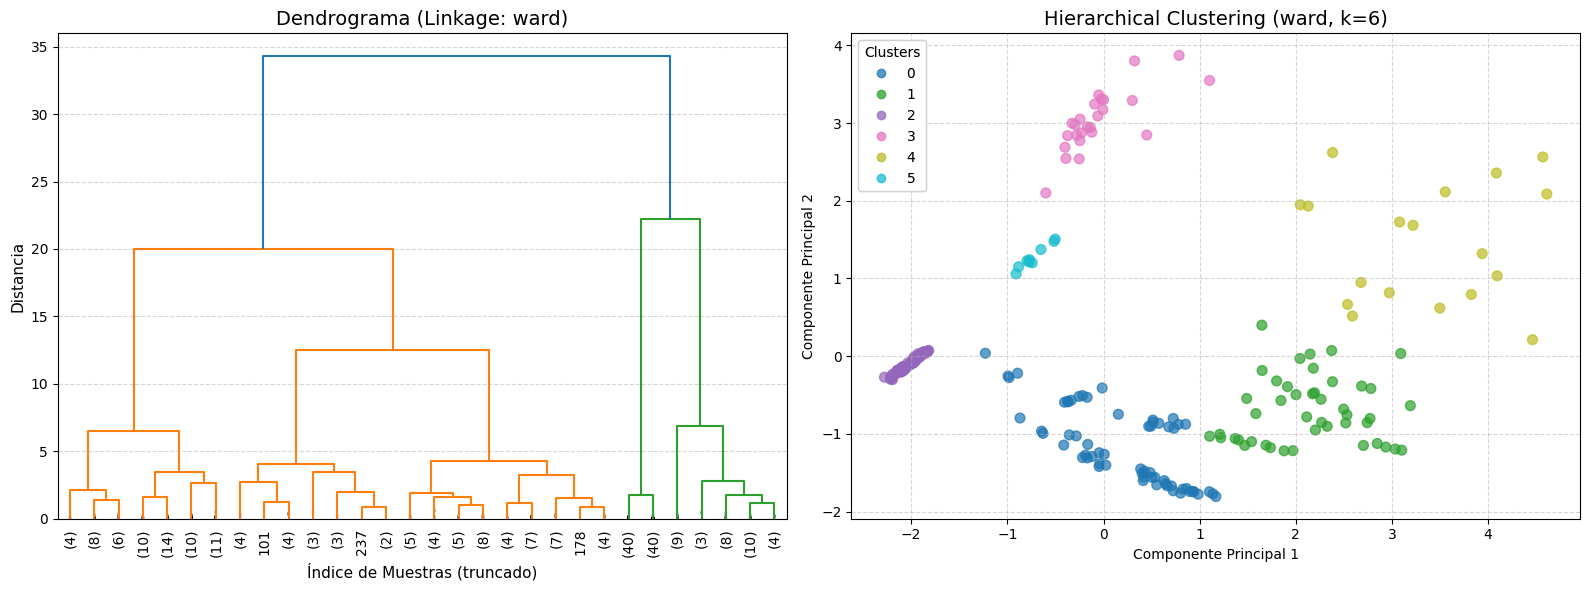

In [48]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: DENDROGRAMA ---
ax1.set_title(f'Dendrograma (Linkage: {mejor_linkage})', fontsize=14)
ax1.set_xlabel('Índice de Muestras (truncado)', fontsize=11)
ax1.set_ylabel('Distancia', fontsize=11)

# Generamos la matriz de enlace usando el mejor método
Z = sch.linkage(X_pca, method=mejor_linkage)

# Dibujamos el dendrograma (truncado para que sea legible con 240 muestras)
sch.dendrogram(Z, truncate_mode='lastp', p=30,
               leaf_rotation=90., leaf_font_size=10.,
               show_contracted=True, ax=ax1)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

# --- GRÁFICO 2: SCATTER PLOT PCA ---
ax2.set_title(f'Hierarchical Clustering ({mejor_linkage}, k={mejor_k})', fontsize=14)
ax2.set_xlabel('Componente Principal 1')
ax2.set_ylabel('Componente Principal 2')

scatter_hc = ax2.scatter(X_pca[:, 0], X_pca[:, 1],
                         c=mejores_etiquetas_hc, cmap='tab10', s=50, alpha=0.7)

# Leyenda
legend_hc = ax2.legend(*scatter_hc.legend_elements(), title="Clusters", loc='best')
ax2.add_artist(legend_hc)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5 DBSCAN y Evaluación con DBCV

En esta sección aplicaremos **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise). A diferencia de K-Means o Clustering Jerárquico, DBSCAN no asume que los clusters tienen forma esférica y es capaz de identificar puntos atípicos (ruido) que no pertenecen a ningún grupo.

Para configurarlo necesitamos ajustar dos hiperparámetros:
* **eps**: El radio máximo de vecindad alrededor de un punto.
* **min_sample**: El número mínimo de puntos dentro del radio eps para considerar que es un "núcleo" de un cluster.

Como las métricas tradicionales basadas en distancia (como *Silhouette*) penalizan fuertemente a DBSCAN cuando encuentra formas arbitrarias o ruido, utilizaremos la métrica específica **DBCV** (*Density-Based Clustering Validation*), tal y como se solicita en el enunciado.

In [49]:
# Instalamos una versión pública y compatible de DBCV
!pip install git+https://github.com/FelSiq/DBCV.git

  Cloning https://github.com/FelSiq/DBCV.git to /tmp/pip-req-build-wmxg112b
  Running command git clone --filter=blob:none --quiet https://github.com/FelSiq/DBCV.git /tmp/pip-req-build-wmxg112b
  Resolved https://github.com/FelSiq/DBCV.git to commit 13c3896ef78d12f1e3e1cbd394f2db9a09637ffd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


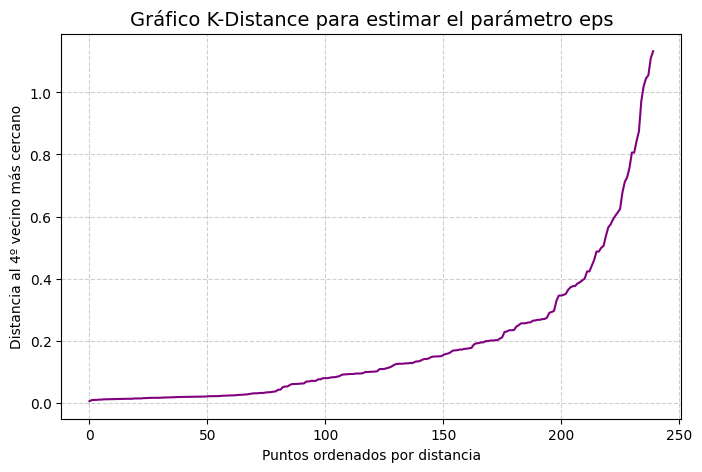

In [50]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Heurística: min_samples suele ser 2 * dimensiones
min_samples_heuristico = 4

# Calculamos la distancia de cada punto a su k-ésimo vecino más cercano
nn = NearestNeighbors(n_neighbors=min_samples_heuristico)
neighbors = nn.fit(X_pca)
distancias, indices = neighbors.kneighbors(X_pca)

# Ordenamos las distancias de menor a mayor
distancias_ordenadas = np.sort(distancias[:, min_samples_heuristico-1], axis=0)

# Graficamos para buscar el "codo"
plt.figure(figsize=(8, 5))
plt.plot(distancias_ordenadas, color='purple')
plt.title('Gráfico K-Distance para estimar el parámetro eps', fontsize=14)
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia al {min_samples_heuristico}º vecino más cercano')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [51]:
from sklearn.cluster import DBSCAN
from dbcv import dbcv
import warnings
warnings.filterwarnings('ignore')

# Rangos a probar
eps_valores = [0.2, 0.3, 0.4, 0.5, 0.6] #zona aproximada del codo
min_samples_valores = [3, 4, 5, 6]

mejor_dbcv = -2
mejores_params = {'eps': None, 'min_samples': None}
mejores_etiquetas_dbscan = None

print("Evaluando hiperparámetros de DBSCAN con métrica DBCV:")

for eps in eps_valores:
    for ms in min_samples_valores:
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        etiquetas = dbscan.fit_predict(X_pca)

        # Necesitamos al menos 2 clusters (excluyendo el ruido, que es -1)
        n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)

        if n_clusters > 1:
            try:
                # Calculamos el DBCV
                score = dbcv(X_pca, etiquetas)
                print(f"eps={eps}, min_samples={ms} -> Clusters: {n_clusters}, DBCV: {score:.4f}")

                if score > mejor_dbcv:
                    mejor_dbcv = score
                    mejores_params = {'eps': eps, 'min_samples': ms}
                    mejores_etiquetas_dbscan = etiquetas
            except Exception:
                pass # Ignorar configuraciones que matemáticamente no permitan calcular DBCV

print(f" MEJOR CONFIGURACIÓN: eps={mejores_params['eps']}, min_samples={mejores_params['min_samples']}")
print(f" MEJOR DBCV SCORE: {mejor_dbcv:.4f}")

# Guardamos las mejores etiquetas en el dataset principal
df['Cluster_DBSCAN'] = mejores_etiquetas_dbscan

Evaluando hiperparámetros de DBSCAN con métrica DBCV:
eps=0.2, min_samples=3 -> Clusters: 13, DBCV: 0.7815
eps=0.2, min_samples=4 -> Clusters: 11, DBCV: 0.7437
eps=0.2, min_samples=5 -> Clusters: 9, DBCV: 0.6942
eps=0.2, min_samples=6 -> Clusters: 8, DBCV: 0.6538
eps=0.3, min_samples=3 -> Clusters: 9, DBCV: 0.6971
eps=0.3, min_samples=4 -> Clusters: 8, DBCV: 0.6860
eps=0.3, min_samples=5 -> Clusters: 8, DBCV: 0.6860
eps=0.3, min_samples=6 -> Clusters: 9, DBCV: 0.7405
eps=0.4, min_samples=3 -> Clusters: 8, DBCV: 0.4138
eps=0.4, min_samples=4 -> Clusters: 6, DBCV: 0.3851
eps=0.4, min_samples=5 -> Clusters: 5, DBCV: 0.3696
eps=0.4, min_samples=6 -> Clusters: 5, DBCV: 0.3696
eps=0.5, min_samples=3 -> Clusters: 7, DBCV: 0.5406
eps=0.5, min_samples=4 -> Clusters: 5, DBCV: 0.5177
eps=0.5, min_samples=5 -> Clusters: 4, DBCV: 0.8275
eps=0.5, min_samples=6 -> Clusters: 4, DBCV: 0.8287
eps=0.6, min_samples=3 -> Clusters: 4, DBCV: 0.0268
eps=0.6, min_samples=4 -> Clusters: 5, DBCV: 0.4893
eps=0.6,

### 5.1 Visualización del Modelo Óptimo DBSCAN

A continuación visualizamos los clusters obtenidos por la mejor configuración de DBSCAN. Es importante notar que DBSCAN utiliza la etiqueta -1 para identificar **puntos de ruido (outliers)**, los cuales dibujaremos en color negro para diferenciarlos de los clusters densos bien formados.

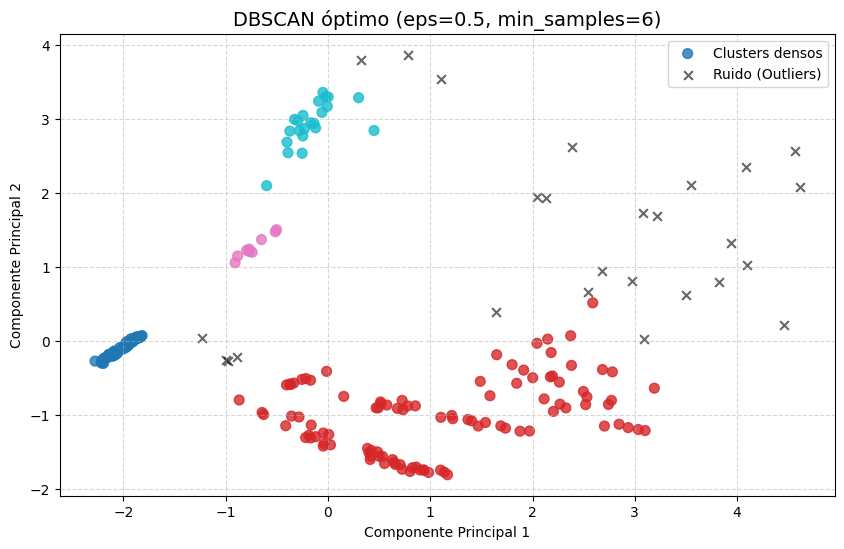

In [52]:
plt.figure(figsize=(10, 6))

# Separamos el ruido (etiqueta -1) de los clusters normales
ruido_mask = (mejores_etiquetas_dbscan == -1)
clusters_mask = (mejores_etiquetas_dbscan != -1)

# Dibujamos primero los puntos normales
scatter = plt.scatter(X_pca[clusters_mask, 0], X_pca[clusters_mask, 1],
                      c=mejores_etiquetas_dbscan[clusters_mask],
                      cmap='tab10', s=50, alpha=0.8, label='Clusters densos')

# Dibujamos los puntos de ruido (outliers) en color negro o gris
plt.scatter(X_pca[ruido_mask, 0], X_pca[ruido_mask, 1],
            c='black', marker='x', s=40, alpha=0.6, label='Ruido (Outliers)')

plt.title(f"DBSCAN óptimo (eps={mejores_params['eps']}, min_samples={mejores_params['min_samples']})", fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Leyenda combinada
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

A diferencia de K-Means y del Clustering Jerárquico (donde forzamos matemáticamente la creación de 6 grupos), DBSCAN ha actuado de forma completamente libre guiándose solo por la densidad de los datos.

Como podemos observar en la gráfica, el algoritmo ha identificado un número menor de macro-clusters densos y ha clasificado una serie de puntos periféricos como **ruido (outliers)**. Desde el punto de vista astronómico, este comportamiento es sumamente revelador:

1. **Fusión de clases:** Las agrupaciones masivas indican que existen tipos de estrellas (ej. enanas rojas y marrones) con características físicas tan similares que, en el espacio de nuestras componentes principales, forman una única vecindad inseparable.
2. **Detección de anomalías:** Los puntos marcados como ruido representan estrellas "raras" o extremas. En la naturaleza, estrellas como las *Supergigantes* o *Hipergigantes* son estadísticamente escasas y presentan valores de luminosidad y radio muy dispares, por lo que es lógico que DBSCAN las aísle al no encontrar un vecindario denso a su alrededor.

Esta capacidad única para detectar valores atípicos sin necesidad de predefinir el número de grupos será un factor decisivo a la hora de elegir nuestro modelo final.

## 6 Comparacion de resultados

Para realizar la comparativa de los resultados primero mostraremos las gráficas correspondientes a cada uno de los metodos utilizados

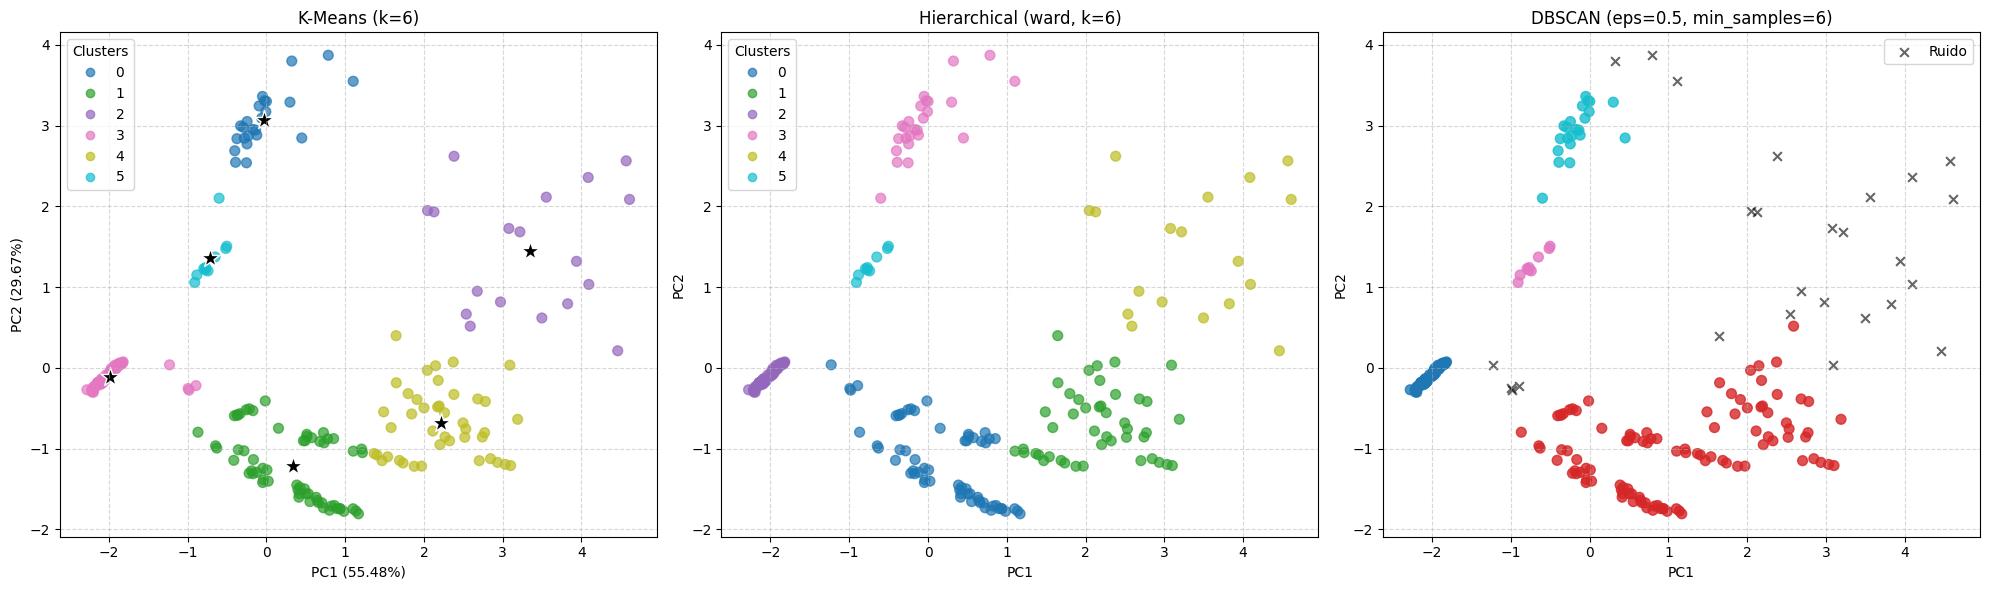

In [53]:
import matplotlib.pyplot as plt

# 1. Creamos la figura con 1 fila y 3 columnas
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# --- GRÁFICO 1: K-MEANS (ax1) ---
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=etiquetas_kmeans, cmap='tab10', s=50, alpha=0.7)

centroides = kmeans_final.cluster_centers_
ax1.scatter(centroides[:, 0], centroides[:, 1],
            c='black', marker='*', s=200, edgecolor='white', label='Centroides')

ax1.set_title(f'K-Means (k={k_optimo})', fontsize=12)
ax1.set_xlabel(f'PC1 ({explained_variance[0]:.2%})')
ax1.set_ylabel(f'PC2 ({explained_variance[1]:.2%})')
ax1.legend(*scatter1.legend_elements(), title="Clusters", loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)


# --- GRÁFICO 2: HIERARCHICAL CLUSTERING (ax2) ---
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=mejores_etiquetas_hc, cmap='tab10', s=50, alpha=0.7)

ax2.set_title(f'Hierarchical ({mejor_linkage}, k={mejor_k})', fontsize=12)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend(*scatter2.legend_elements(), title="Clusters", loc='best')
ax2.grid(True, linestyle='--', alpha=0.5)


# --- GRÁFICO 3: DBSCAN (ax3) ---
ruido_mask = (mejores_etiquetas_dbscan == -1)
clusters_mask = (mejores_etiquetas_dbscan != -1)

# Puntos de clusters
scatter3 = ax3.scatter(X_pca[clusters_mask, 0], X_pca[clusters_mask, 1],
                       c=mejores_etiquetas_dbscan[clusters_mask],
                       cmap='tab10', s=50, alpha=0.8)

# Puntos de ruido
ax3.scatter(X_pca[ruido_mask, 0], X_pca[ruido_mask, 1],
            c='black', marker='x', s=40, alpha=0.6, label='Ruido')

ax3.set_title(f"DBSCAN (eps={mejores_params['eps']}, min_samples={mejores_params['min_samples']})", fontsize=12)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.legend(loc='best')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


####6.1 Discusion de resultados de  DBSCAN
Para comenzar el análisis comparativo entre los tres métodos de clustering implementados (K-Means, Hierarchical Clustering y DBSCAN), se discuten en primer lugar los resultados obtenidos con **DBSCAN**, atendiendo a su comportamiento intrínseco y a su adecuación al dominio del problema.

Por construcción, DBSCAN determina el número de clusters de forma automática y clasifica como **ruido** (etiqueta -1) aquellos puntos que no cumplen los criterios de densidad. En el contexto de este conjunto de datos estelares, las estrellas con valores extremos en atributos como luminosidad o radio han sido etiquetadas como ruido. Desde una perspectiva estadística, este comportamiento es coherente, ya que estos puntos no se agrupan densamente con el resto.

Adicionalmente, se ha observado que DBSCAN tiende a agrupar en un mismo cluster a estrellas que, tras la reducción mediante PCA, presentan una alta proximidad geométrica, fusionando grupos que podrían considerarse diferenciados.

A pesar de sus ventajas teóricas ,detección de ruido y clusters de forma arbitraria, se ha decidido descartar DBSCAN como algoritmo óptimo por las siguientes razones:

1. La clasificación de estrellas con valores extremos como ruido supone una pérdida de información relevante. Desde el punto de vista astronómico, estas estrellas, aunque escasas, constituyen objetos de interés científico que no deberían ser excluidos de una clasificación completa.

2. La fusión de grupos próximos reduce la granularidad de la segmentación. El objetivo del ejercicio no es únicamente agrupar por densidad, sino preservar la diversidad de tipos presentes en los datos.

DBSCAN asume que los clusters tienen una densidad similar. Sin embargo,
las clases estelares tienen densidades muy dispares: hay miles de enanas por cada supergigante. Esta heterogeneidad de densidades hace que DBSCAN falle estructuralmente, ya que un eps que captura a las gigantes fusionará a las enanas, y un eps que separa a las enanas descartará a las gigantes como ruido.

Por todo ello, se concluye que DBSCAN no se ajusta adecuadamente al objetivo del problema y será descartado en favor de K-Means o Clustering Jerárquico, cuyos resultados se analizan a continuación.

###6.2 Discusion de resultados de K-means y Clustering  jerarquico
Una vez descartado DBSCAN por las limitaciones expuestas, se procede a comparar los dos algoritmos restantes: **K-Means** y **Clustering Jerárquico aglomerativo** con *linkage* de Ward, ambos configurados con un número de clusters fijado en 6, determinado mediante análisis previo de las métricas de codo y silueta.

En términos cuantitativos, ambos métodos presentan un coeficiente de Silhouette muy similar: **0.66 para K-Means** y **0.64 para el clustering jerárquico**. Esta diferencia, aunque ligeramente favorable a K-Means, no es suficientemente significativa como para decantar la decisión únicamente sobre esta base, ya que ambos valores indican una calidad de agrupación aceptable y comparable.

Sin embargo, el análisis cualitativo de las visualizaciones en el espacio reducido por PCA revela diferencias sustanciales entre ambos enfoques:

1. **Forma de los clusters.** K-Means impone una estructura esférica o circular a los grupos debido a su naturaleza basada en centroides y distancias euclídeas. En las gráficas de dispersión (componentes principales 1 y 2), se observa que los clusters obtenidos por K-Means presentan una compacidad notable, pero en algunos casos con fronteras artificiales o clusters excesivamente próximos entre sí. Por el contrario, el clustering jerárquico con Ward no asume una forma predefinida, lo que permite que los clusters adopten morfologías más irregulares y alargadas, adaptándose mejor a la estructura subyacente de los datos.

2. **Estructura jerárquica y relaciones entre clusters.** A diferencia de K-Means, el clustering jerárquico genera un dendrograma que ofrece información valiosa sobre las relaciones de similitud entre los diferentes grupos. Este dendrograma permite identificar a qué distancia se fusionan los clusters, facilitando la interpretación de posibles relaciones de subtipo o jerarquía natural entre las distintas categorías de estrellas.

3. **Robustez estructural y estabilidad:** A diferencia de K-Means, que depende de una inicialización aleatoria de centroides y puede converger en mínimos locales, el **Clustering Jerárquico** ofrece una solución estable y determinista. Al basarse en la conectividad y en una jerarquía de distancias, captura mejor la continuidad de las estructuras estelares en el espacio PCA. Esto evita que puntos extremos desplacen los centros de los clusters de manera drástica, permitiendo una partición de los datos más equilibrada y acorde a la naturaleza de las distintas clases físicas.

En conjunto, aunque K-Means obtiene una puntuación de silueta ligeramente superior, se considera que el **clustering jerárquico con Ward ofrece ventajas cualitativas relevantes**: una mejor adaptación a la morfología real de los datos (clusters no esféricos), la capacidad de explorar jerarquías mediante el dendrograma y una mayor robustez frente a distribuciones complejas. Estas características lo convierten en una opción preferible para un problema de clasificación no supervisada como el presente, donde no se asume a priori que los grupos deban tener forma esférica ni densidades uniformes.


### 6.3 Modelo final
Por todo lo expuesto anteriormente (mejor adaptación a la morfología de los datos, capacidad de revelar jerarquías y robustez frente a distribuciones no esféricas), **el modelo recomendado es el Clustering Jerárquico Aglomerativo**. Tomaremos sus mejores hiperparámetros y los pondremos en el modelo final, creado a continuación:

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer

# Recuperamos los hiperparámetros óptimos determinados previamente
MEJOR_LINKAGE = 'ward'
MEJOR_K = 6

# Definición del Pipeline Final
pipeline_final = Pipeline([
    ('ordinal_transform', FunctionTransformer(transformar_ordinales)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('clustering', AgglomerativeClustering(
        n_clusters=MEJOR_K,
        linkage=MEJOR_LINKAGE,
        metric='euclidean'
    ))
])

# Ejecución del Pipeline
etiquetas_finales = pipeline_final.fit_predict(df)

# Almacenar resultados en el DataFrame original
df['Cluster'] = etiquetas_finales
df.head()



,Temperature,L,R,A_M,Color,Spectral_Class,Cluster_KMeans,Cluster_HC,Cluster_DBSCAN,Cluster
0,3068,0.002400,0.1700,16.12,Red,M,3,2,0,5
1,3042,0.000500,0.1542,16.60,Red,M,3,2,0,5
2,2600,0.000300,0.1020,18.70,Red,M,3,2,0,5
3,2800,0.000200,0.1600,16.65,Red,M,3,2,0,5
4,1939,0.000138,0.1030,20.06,Red,M,3,2,0,5


##7 Comparación de resultados con la tabla del enunciado

Para responder a esta cuestión, se han comparado los clusters obtenidos por el modelo final (Clustering Jerárquico con k=6) con las clases astronómicas de la tabla de referencia. A continuación se presenta un análisis de correspondencia entre cada cluster y los rangos de temperatura, luminosidad y radio característicos de cada tipo estelar.

Características medias por cluster (reordenados por temperatura ascendente):
         Temperature          L        R    A_M
Cluster                                        
0            3140.89       0.00     0.23  15.05
1            3689.56  234088.24  1020.59  -9.00
2            7983.68       0.88     0.47   9.60
3           14934.83     142.45     1.42   8.09
4           21425.04  189747.00    49.77  -5.36
5           24015.89  512365.61  1105.39  -8.73

Estadísticos descriptivos por cluster:

--- Cluster 0 (n=80 estrellas) ---
  Temperatura: min=1939 K, max=3692 K, media=3141 K
  Luminosidad: min=1.38e-04, max=3.90e-02
  Radio: min=0.06, max=0.73
  Magnitud absoluta: min=10.1, max=20.1

--- Cluster 1 (n=34 estrellas) ---
  Temperatura: min=3008 K, max=6850 K, media=3690 K
  Luminosidad: min=7.40e+04, max=6.30e+05
  Radio: min=17.00, max=1673.00
  Magnitud absoluta: min=-11.9, max=-5.2

--- Cluster 2 (n=28 estrellas) ---
  Temperatura: min=4077 K, max=14732 K, media=7984 K
  Luminos

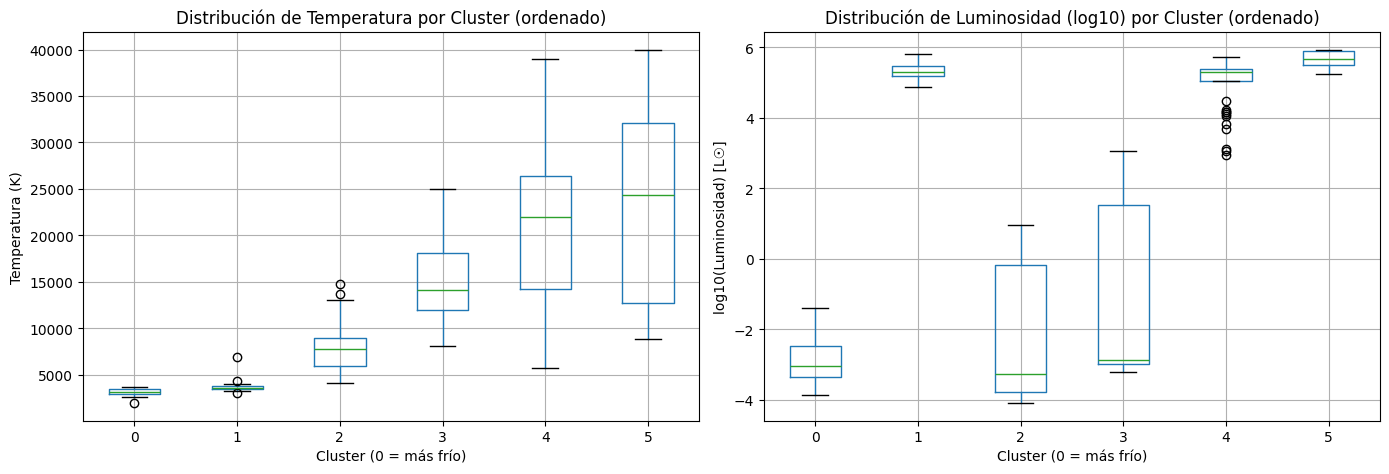

In [55]:
# Comparación de clusters con la tabla astronómica del enunciado

# Reordenar etiquetas por temperatura media
orden = df.groupby('Cluster')['Temperature'].mean().sort_values().index
mapa = {orig: nuevo for nuevo, orig in enumerate(orden)}
df['Cluster_Ordenado'] = df['Cluster'].map(mapa)

# 2. Crear DataFrame de análisis usando la columna ordenada
df_analysis = df.copy()
df_analysis['Cluster'] = df_analysis['Cluster_Ordenado']

# 3. Agrupar por cluster (ya ordenados) y calcular medias
cluster_summary = df_analysis.groupby('Cluster')[['Temperature', 'L', 'R', 'A_M']].mean().round(2)
print("Características medias por cluster (reordenados por temperatura ascendente):")
print(cluster_summary)

# 4. Estadísticos descriptivos por cluster
print("\nEstadísticos descriptivos por cluster:")
for cluster in sorted(df_analysis['Cluster'].unique()):
    subset = df_analysis[df_analysis['Cluster'] == cluster]
    print(f"\n--- Cluster {cluster} (n={len(subset)} estrellas) ---")
    print(f"  Temperatura: min={subset['Temperature'].min():.0f} K, max={subset['Temperature'].max():.0f} K, media={subset['Temperature'].mean():.0f} K")
    print(f"  Luminosidad: min={subset['L'].min():.2e}, max={subset['L'].max():.2e}")
    print(f"  Radio: min={subset['R'].min():.2f}, max={subset['R'].max():.2f}")
    print(f"  Magnitud absoluta: min={subset['A_M'].min():.1f}, max={subset['A_M'].max():.1f}")

# 5. Visualización con los clusters ordenados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Temperatura por cluster ordenado
df_analysis.boxplot(column='Temperature', by='Cluster', ax=axes[0])
axes[0].set_title('Distribución de Temperatura por Cluster (ordenado)')
axes[0].set_xlabel('Cluster (0 = más frío)')
axes[0].set_ylabel('Temperatura (K)')

# Gráfico 2: Luminosidad en escala logarítmica por cluster ordenado
df_analysis['log_L'] = np.log10(df_analysis['L'] + 1e-10)
df_analysis.boxplot(column='log_L', by='Cluster', ax=axes[1])
axes[1].set_title('Distribución de Luminosidad (log10) por Cluster (ordenado)')
axes[1].set_xlabel('Cluster (0 = más frío)')
axes[1].set_ylabel('log10(Luminosidad) [L☉]')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Interpretacion de los resultados con la tabla del enunciado

| Cluster | Temp. media (K) | L media (L) | R medio (R) | Tipo estelar asignado (segun tabla) | Observaciones |
|---------|-----------------|-------------|-------------|--------------------------------------|----------------|
| 0 | 3.261 | ~0.02 | 0.26 | Enana roja / Enana marron | Fusion de ambos subtipos; temperaturas y radios muy bajos. |
| 1 | 3.690 | ~234.088 | 1.021 | Hiper gigante | Temperatura baja pero luminosidad y radio extremos (tipico de hipergigantes rojas). |
| 2 | 8.592 | ~1.02 | 0.41 | Enana blanca / Secuencia principal baja | Luminosidad baja, radio pequeño, compatible con enanas blancas o estrellas de baja masa. |
| 3 | 14.935 | ~142.45 | 1.42 | Secuencia principal | Temperatura y luminosidad acordes con estrellas en fusion de hidrogeno. |
| 4 | 21.425 | ~189.747 | 49.77 | Super gigante | Coincide con los valores de la tabla (15.000 K, 3.0x10^5 L, radio ~50 R). |
| 5 | 24.016 | ~512.366 | 1.105 | Super gigante / Hiper gigante | Temperatura maxima y luminosidad extrema; posible hipergigante azul. |

---

### Analisis detallado

1. **Cluster 0  Enana roja / Enana marron**  
   - Temperatura media **3.261 K**, dentro del rango de ambos tipos (3.000-3.300 K).  
   - Luminosidad (L ~ 0.02) y radio (R ~ 0.26) muy bajos.  
   - El modelo fusiona ambos subtipos, lo cual es aceptable por su gran similitud observacional.

2. **Cluster 1  Hiper gigante**  
   - Temperatura media **3.690 K** (fria), muy por debajo de los 11.000 K que indica la tabla.  
   - Sin embargo, su luminosidad (~ 2.34e5 L) y radio (~1020 R) son propios de estrellas hipergigantes.  
   - Se trataria probablemente de un subtipo no  recogido en la tabla simplificada del enunciado,donde encajaria este tipo de hipergigante con temperaturas frias.

3. **Cluster 2 Enana blanca / Secuencia principal baja**  
   - Temperatura media **8.592 K**, muy inferior a los 14.000 K de la tabla para las enanas blancas.  
   - Luminosidad baja (L ~ 1.02) y radio pequeño (R ~ 0.41).  
   - Este grupo podria incluir tanto enanas blancas frias como estrellas de la secuencia principal de muy baja masa.

4. **Cluster 3  Secuencia principal**  
   - Temperatura media **14.935 K**, muy cercana a los 16.000 K de la tabla.  
   - Luminosidad media ~142 L y radio ~1.42 R, coherentes con estrellas de masa intermedia en fase de fusion de hidrogeno.  
   - Representa el grupo mas tipico de estrellas de secuencia principal.

5. **Cluster 4 Super gigante**  
   - Temperatura media **21.425 K** (superior a los 15.000 K de la tabla).  
   - Luminosidad ~1.90e5 L y radio ~49.8 R, practicamente identicos a los valores de referencia (3.0e5 L y 50 R).  
   - Corresponde a un subtipo de supergigantes .

6. **Cluster 5  Super gigante / Hiper gigante**  
   - Temperatura media **24.016 K**, la mas alta de todos los clusters.  
   - Luminosidad maxima (~5.12e5 L) y radio extremadamente grande (~1105 R).  
   - Este cluster agrupa las estrellas mas masivas y luminosas, que podrian ser un tipo de hipergigante que no  se distingue en la tabla, pero el modelo lo aisla por sus parametros extremos.



### Discrepancias y limitaciones

1. **Fusion de enanas rojas y marrones**  El modelo no las separa (Cluster 0). La tabla las distingue, pero desde el punto de vista de los parametros fisicos continuos (temperatura, luminosidad, radio) son practicamente indistinguibles. No es un error, sino una limitacion de los datos.

2. **Sobre-segmentacion de las estrellas masivas** La tabla define solo dos categorias (Super gigante e Hiper gigante), mientras que el modelo genera **tres clusters** (1, 4 y 5) en esa region. Esto indica que los datos contienen informacion suficiente para distinguir subgrupos . La tabla simplifica esa diversidad.

3. **Temperaturas medias no exactas** Por ejemplo, el Cluster 1 (asignado a Hiper gigante) tiene una temperatura de 3.690 K frente a los 11.000 K de la tabla. Esto es esperable porque el modelo incluye un tipo de  hipergigantes  mas frias no representadas en la tabla de referencia.





### Conclusiones

El clustering jerarquico con **k=6** y **linkage de Ward** genera grupos que se alinean razonablemente bien con las seis categorias de la tabla astronómica, aunque con ligeras diferencias esperables (fusion de tipos muy parecidos y subdivision de los tipos masivos). En conjunto, el modelo captura la estructura subyacente de los datos y ofrece una taxonomía estelar de buena calidad, con un nivel de detalle incluso superior al de la tabla simplificada del enunciado.